# Trabajo Práctico: Modelos de Difusión para la Generación de Imágenes

## Introducción

Los modelos de difusión son una clase de modelos generativos que aprenden a generar datos de alta calidad revirtiendo un proceso de ruido progresivo. A medida que el modelo se entrena, aprende a deshacer el ruido para recuperar las imágenes originales. En este trabajo práctico, utilizaremos un modelo de difusión preentrenado para generar imágenes del conjunto de datos **CIFAR-10**, un dataset comúnmente usado en visión por computadora que contiene imágenes de 32x32 píxeles de 10 clases diferentes (como perros, gatos, automóviles, etc.).

A lo largo de este notebook, exploraremos cómo el modelo genera imágenes a partir de ruido y cómo diferentes parámetros afectan este proceso.

In [1]:
# Instalamos las librerías necesarias
#!pip install transformers diffusers imageio -q

## Parte 1: Preparación del entorno

Primero, instalaremos y cargaremos las librerías necesarias. Utilizaremos **PyTorch** y el modelo preentrenado desde **Hugging Face**.

In [2]:
import warnings
warnings.filterwarnings("ignore")
import torch
import time
import imageio
import numpy as np
from torchvision import transforms
from torchvision.utils import save_image, make_grid
from diffusers import DDPMPipeline
from matplotlib import pyplot as plt
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import os

# Crear las carpetas './imgs' y './grid' si no existen
os.makedirs("./imgs", exist_ok=True)
os.makedirs("./grid", exist_ok=True)
os.makedirs("./gifs", exist_ok=True)

## Parte 2: Cargar el modelo preentrenado

Vamos a utilizar un modelo de difusión preentrenado en **CIFAR-10**. Hugging Face ofrece un pipeline ya entrenado que facilita la generación de imágenes.

El modelo pre-entrenado a utilizar se llama DDPM (Denoising Diffusion Probabilistic Models) de Jonathan Ho, Ajay Jain and Pieter Abbeel. Se puede encontrar la documentación en el siguiente link https://huggingface.co/docs/diffusers/api/pipelines/ddpm

In [3]:
# Cargamos el modelo preentrenado DDPMPipeline para CIFAR-10
model_id = "google/ddpm-cifar10-32"
pipeline = DDPMPipeline.from_pretrained(model_id)
pipeline

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]An error occurred while trying to fetch C:\Users\Enrique\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Enrique\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00, 10.87it/s]


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.35.2",
  "_name_or_path": "google/ddpm-cifar10-32",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

## Parte 3: Generación de imágenes a partir de ruido

En esta sección, generaremos imágenes usando el modelo preentrenado. Cada imagen comenzará como ruido y el modelo lo "des-noiseará" gradualmente para producir una imagen reconocible.

El proceso de generación toma un número de **timesteps**, que son los pasos intermedios durante los cuales el modelo elimina progresivamente el ruido para obtener una imagen. Podemos ajustar el número de timesteps para ver cómo afecta a la calidad de la imagen.

### Ejercicio:
- ¿Qué sucede durante los "timesteps" en el proceso de generación de imágenes utilizando modelos de difusión?
- ¿Por qué comenzamos con una imagen completamente de ruido? ¿Qué papel juega el ruido en el proceso de generación de imágenes?
- Si la imagen original está completamente cubierta de ruido, ¿cómo es posible que el modelo aprenda a des-noisearla hasta obtener una imagen clara?

**Respuestas:**

En cada timestep el modelo va quitando un poco de ruido de la imagen. El modelo fue entrenado para predecir cuánto ruido hay en cada paso y lo va eliminando de a poco hasta llegar a una imagen clara.

Comenzamos con ruido porque el modelo fue entrenado de esa forma, aprendiendo a partir de puro ruido. El ruido es el punto de partida, como una semilla de la que crece la imagen.

El modelo aprende durante el entrenamiento a predecir el ruido que se le agregó a las imágenes reales. Entonces cuando generamos, va revirtiendo ese proceso, quitando el ruido que predice en cada paso hasta recuperar una imagen.

In [4]:
def plot_imgs(imgs):
    # Mostrar las imágenes generadas
    plt.figure(figsize=(10, 10))
    for i, img in enumerate(imgs[:16]):
        plt.subplot(4, 4, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()


100%|██████████| 1/1 [00:00<00:00,  2.54it/s]


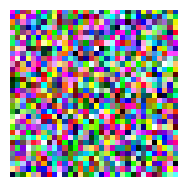

In [5]:
# Generar imágenes
imgs = pipeline(num_inference_steps=1).images
plot_imgs(imgs)

## Parte 4: Explorando los timesteps.

El número de pasos de inferencia (`num_inference_steps`) refiere a los timesteps mencionados anteriormente.

### Ejercicio:
- Completar código.
- Modificar la cantidad de timesteps `num_inference_steps` para ver como varía el resultado (y e tiempo de inferencia) y analizar su impacto.
- ¿Cómo afecta el número de timesteps (pasos de inferencia) a la calidad de las imágenes generadas?
- ¿Cómo describirías visualmente las diferencias entre las imágenes generadas con 10 timesteps y 50 timesteps? ¿Qué esperas observar en cuanto a detalle y nitidez?

**Respuestas:**

Más timesteps significa mejor calidad de imagen pero más tiempo de procesamiento. Con pocos timesteps el modelo no tiene suficientes pasos para quitar todo el ruido y las imágenes quedan borrosas o con artefactos. Con más timesteps el proceso es más gradual y las imágenes salen más nítidas y detalladas.

Con 10 timesteps esperamos ver imágenes más borrosas, menos definidas, con formas poco claras. Con 50 timesteps las imágenes deberían verse más nítidas, con colores mejor definidos y objetos más reconocibles. El tiempo de inferencia aumenta linealmente con los timesteps.

Experimento 1: 10 timesteps


100%|██████████| 10/10 [00:13<00:00,  1.33s/it]


Tiempo de inferencia: 13.30s


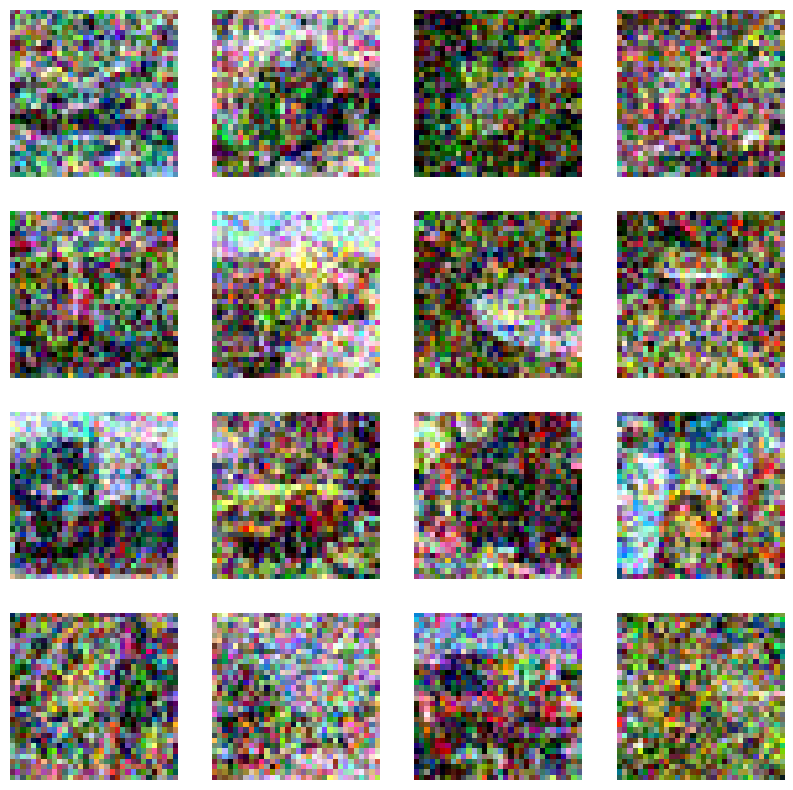

In [6]:
print("Experimento 1: 10 timesteps")
start_time = time.time()
imgs_10 = pipeline(num_inference_steps=10, batch_size=16).images
tiempo_10 = time.time() - start_time
print(f"Tiempo de inferencia: {tiempo_10:.2f}s")
save_image(torch.tensor(np.array(imgs_10[0])).permute(2, 0, 1).unsqueeze(0) / 255.0, "imgs/timesteps_10.png")
plot_imgs(imgs_10)

Experimento 2: 25 timesteps


100%|██████████| 25/25 [00:37<00:00,  1.50s/it]


Tiempo de inferencia: 37.58s


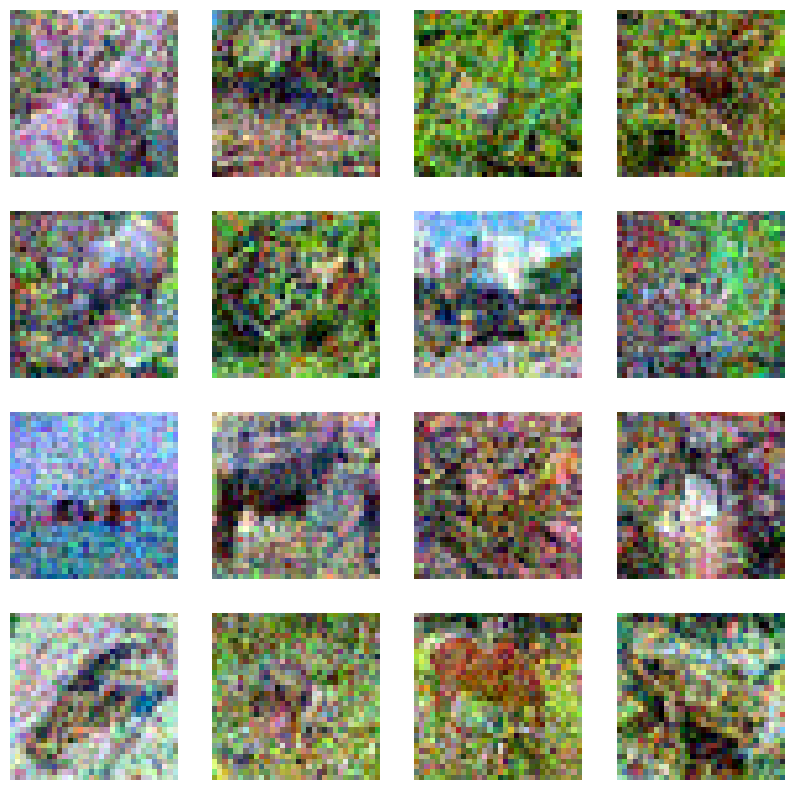

In [7]:
print("Experimento 2: 25 timesteps")
start_time = time.time()
imgs_25 = pipeline(num_inference_steps=25, batch_size=16).images
tiempo_25 = time.time() - start_time
print(f"Tiempo de inferencia: {tiempo_25:.2f}s")
save_image(torch.tensor(np.array(imgs_25[0])).permute(2, 0, 1).unsqueeze(0) / 255.0, "imgs/timesteps_25.png")
plot_imgs(imgs_25)

Experimento 3: 50 timesteps


100%|██████████| 50/50 [00:46<00:00,  1.07it/s]

Tiempo de inferencia: 46.76s


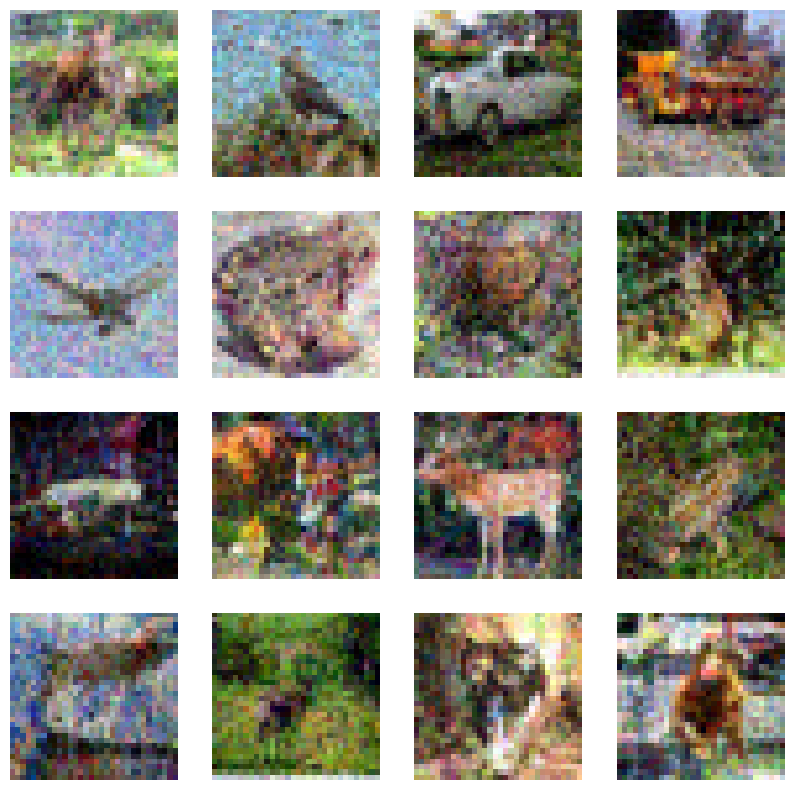

In [8]:
print("Experimento 3: 50 timesteps")
start_time = time.time()
imgs_50 = pipeline(num_inference_steps=50, batch_size=16).images
tiempo_50 = time.time() - start_time
print(f"Tiempo de inferencia: {tiempo_50:.2f}s")
save_image(torch.tensor(np.array(imgs_50[0])).permute(2, 0, 1).unsqueeze(0) / 255.0, "imgs/timesteps_50.png")
plot_imgs(imgs_50)

Experimento 4: 100 timesteps


100%|██████████| 100/100 [02:26<00:00,  1.46s/it]


Tiempo de inferencia: 146.33s


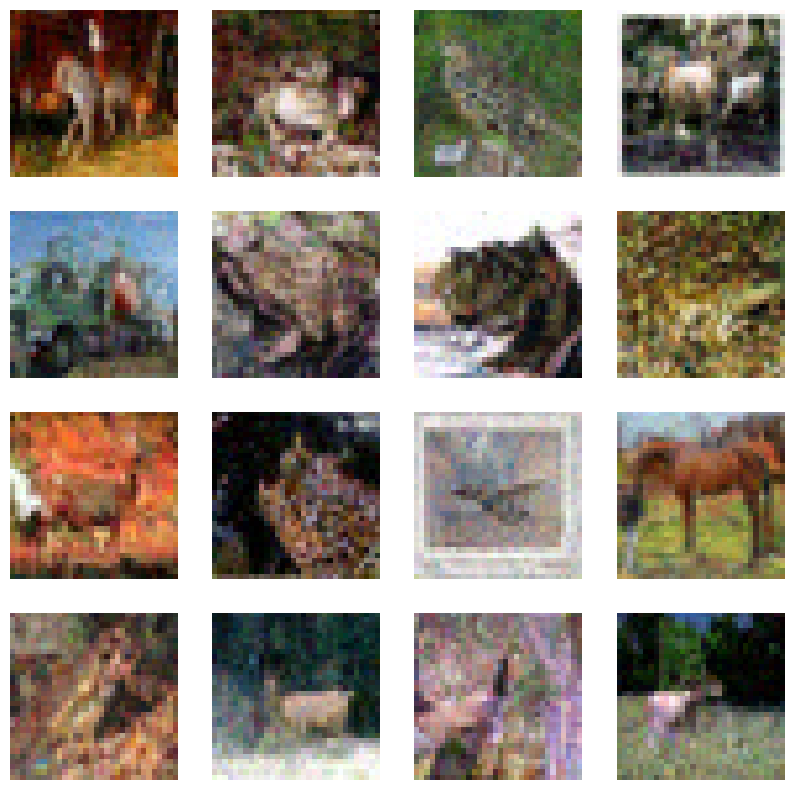


Comparacion de tiempos:
10 timesteps: 13.30s
25 timesteps: 37.58s
50 timesteps: 46.76s
100 timesteps: 146.33s


In [9]:
print("Experimento 4: 100 timesteps")
start_time = time.time()
imgs_100 = pipeline(num_inference_steps=100, batch_size=16).images
tiempo_100 = time.time() - start_time
print(f"Tiempo de inferencia: {tiempo_100:.2f}s")
save_image(torch.tensor(np.array(imgs_100[0])).permute(2, 0, 1).unsqueeze(0) / 255.0, "imgs/timesteps_100.png")
plot_imgs(imgs_100)

print("\nComparacion de tiempos:")
print(f"10 timesteps: {tiempo_10:.2f}s")
print(f"25 timesteps: {tiempo_25:.2f}s")
print(f"50 timesteps: {tiempo_50:.2f}s")
print(f"100 timesteps: {tiempo_100:.2f}s")

## Parte 5: Manipulación del ruido

El ruido es una parte crítica del proceso de difusión. A partir de un ruido aleatorio, el modelo de difusión aprende a generar una imagen. Sin embargo, huggingface nos permite manipular la generación de este ruido pasandole una `seed`.

### Ejercicio
- Completar código.
- ¿Qué es una semilla (seed) y por qué es útil en el proceso de generación de ruido en modelos de difusión?
- ¿Cómo cambia la imagen generada si utilizas diferentes semillas para el ruido inicial? ¿Esperas que dos imágenes generadas con diferentes semillas sean completamente diferentes o tengan similitudes?
- Si utilizas la misma semilla para generar ruido dos veces, ¿esperas obtener la misma imagen al final del proceso de denoising? ¿Por qué?
- Modificar la semilla de generación de ruido para ver cómo varía el resultado y ver cómo impacta en la imagen generada.
- ¿Qué observas cuando cambias la semilla pero mantienes el resto de los parámetros del modelo constante?

**Respuestas:**

Una semilla es un número que inicializa el generador de números aleatorios. Es útil para la reproducibilidad, para poder generar el mismo ruido inicial siempre que usemos la misma semilla.

Con diferentes semillas obtenemos imágenes completamente diferentes. Cada semilla genera un ruido inicial distinto, y como el proceso de denoising parte de ese ruido, las imágenes finales son distintas.

Sí, si usamos la misma semilla dos veces obtenemos exactamente la misma imagen. Esto pasa porque el ruido inicial es el mismo y el proceso de denoising es determinístico.

Experimento 1: Seed 42


100%|██████████| 50/50 [00:48<00:00,  1.03it/s]


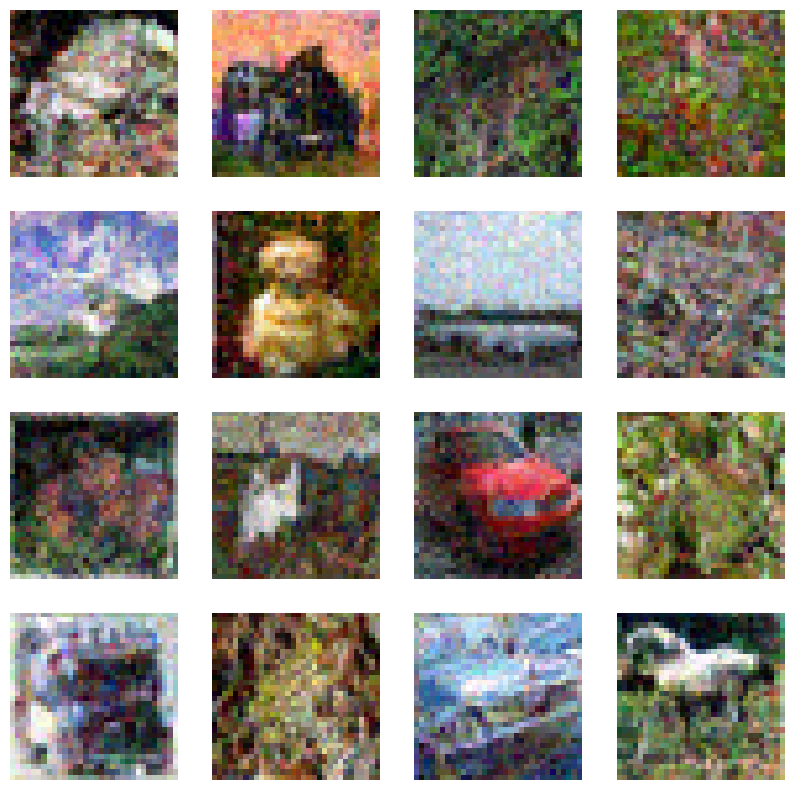

In [10]:
print("Experimento 1: Seed 42")
generator_42 = torch.manual_seed(42)
imgs_seed42_1 = pipeline(num_inference_steps=50, batch_size=16, generator=generator_42).images
save_image(torch.tensor(np.array(imgs_seed42_1[0])).permute(2, 0, 1).unsqueeze(0) / 255.0, "imgs/seed_42_primera.png")
plot_imgs(imgs_seed42_1)

Experimento 2: Seed 123


100%|██████████| 50/50 [01:10<00:00,  1.41s/it]


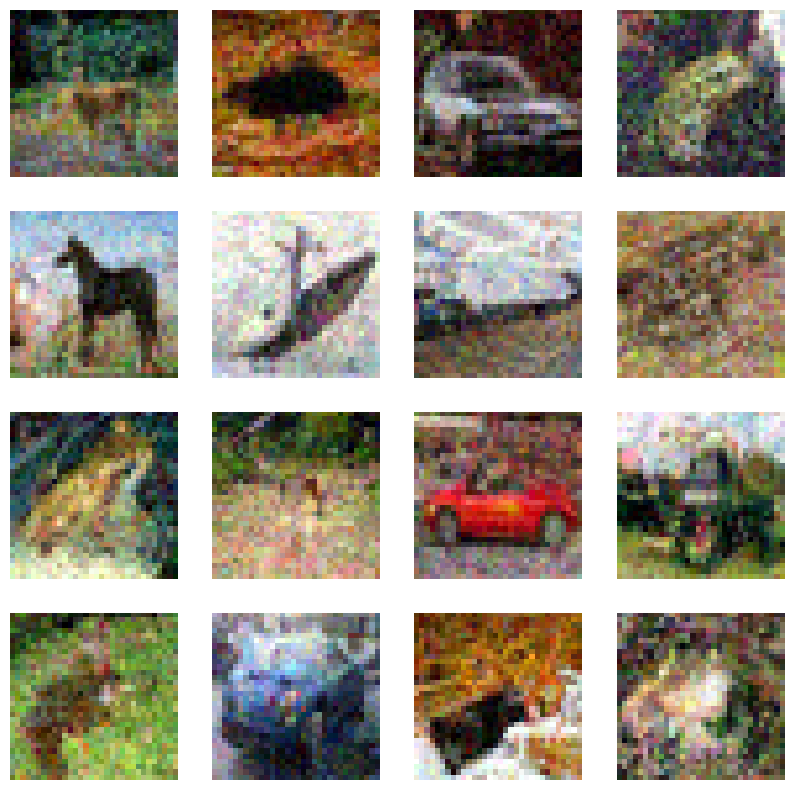

In [11]:
print("Experimento 2: Seed 123")
generator_123 = torch.manual_seed(123)
imgs_seed123 = pipeline(num_inference_steps=50, batch_size=16, generator=generator_123).images
save_image(torch.tensor(np.array(imgs_seed123[0])).permute(2, 0, 1).unsqueeze(0) / 255.0, "imgs/seed_123.png")
plot_imgs(imgs_seed123)

Experimento 3: Seed 42 nuevamente (verificacion de reproducibilidad)


100%|██████████| 50/50 [00:27<00:00,  1.82it/s]


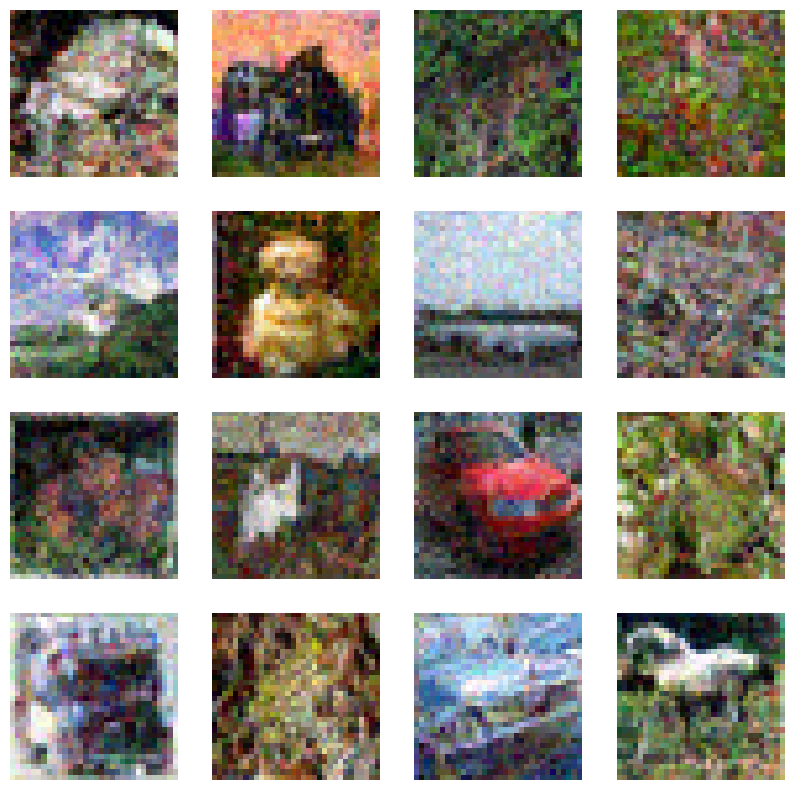


Verificacion: Las imagenes con la misma seed son identicas
Primera imagen con seed 42 == Segunda imagen con seed 42: True


In [12]:
print("Experimento 3: Seed 42 nuevamente (verificacion de reproducibilidad)")
generator_42_2 = torch.manual_seed(42)
imgs_seed42_2 = pipeline(num_inference_steps=50, batch_size=16, generator=generator_42_2).images
save_image(torch.tensor(np.array(imgs_seed42_2[0])).permute(2, 0, 1).unsqueeze(0) / 255.0, "imgs/seed_42_segunda.png")
plot_imgs(imgs_seed42_2)

print("\nVerificacion: Las imagenes con la misma seed son identicas")
print(f"Primera imagen con seed 42 == Segunda imagen con seed 42: {np.array_equal(np.array(imgs_seed42_1[0]), np.array(imgs_seed42_2[0]))}")

## Parte 6: Generación de imágenes en batch y visualización en grilla

Este proceso genera múltiples imágenes a la vez utilizando un **batch size** definido, y luego organiza esas imágenes en una grilla para visualizarlas.

### Proceso:
1. **Batch de ruido**: Se genera un batch de imágenes de ruido gaussiano utilizando un tamaño de batch específico (por ejemplo, `batch_size=8`).
2. **Generación en paralelo**: El pipeline genera varias imágenes en paralelo utilizando el batch de ruido.
3. **Grilla de imágenes**: Las imágenes generadas se organizan en una grilla utilizando la función `torchvision.utils.make_grid`, lo que permite visualizar varias imágenes en una única figura.

### Ejercicio:
- Completar código.
- Compare el tiempo de inferencia cuando genera en paralelo y secuencialmente (una por una).
- Compare el tiempo de inferencia cuando genera varias imagenes en paralelo y una sola.

100%|██████████| 50/50 [01:26<00:00,  1.73s/it]


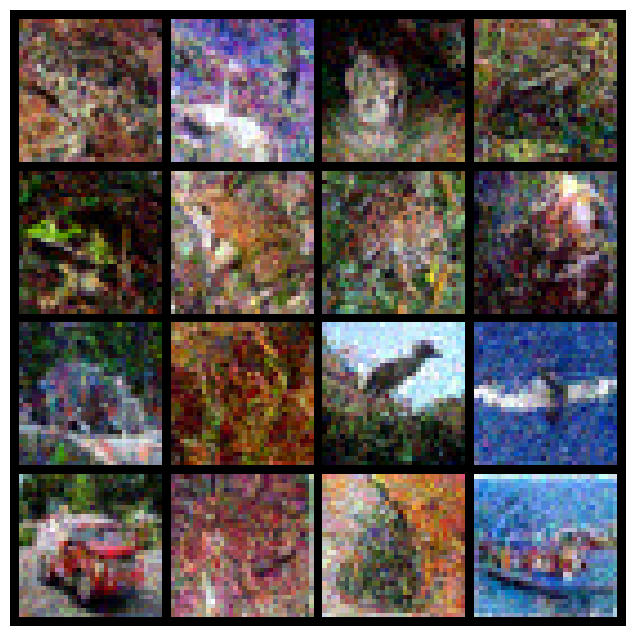

In [13]:
generated_images = pipeline(num_inference_steps=50, batch_size=16).images

image_tensors = [torch.tensor(np.array(img)).permute(2, 0, 1).unsqueeze(0) / 255.0 for img in generated_images]
image_tensors = torch.cat(image_tensors)

grid = make_grid(image_tensors, nrow=4)

save_image(grid, "grid/generated_images_grid.png")

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()

In [14]:
print("Experimento 1: Generacion secuencial (una por una)")
start_time = time.time()
imgs_secuencial = []
for i in range(16):
    img = pipeline(num_inference_steps=50, batch_size=1).images[0]
    imgs_secuencial.append(img)
tiempo_secuencial = time.time() - start_time
print(f"Tiempo de inferencia secuencial (16 imagenes): {tiempo_secuencial:.2f}s")
print(f"Tiempo promedio por imagen: {tiempo_secuencial/16:.2f}s")

Experimento 1: Generacion secuencial (una por una)


100%|██████████| 50/50 [00:18<00:00,  2.69it/s]

Tiempo de inferencia secuencial (16 imagenes): 236.25s
Tiempo promedio por imagen: 14.77s


In [15]:
print("Experimento 2: Generacion en paralelo (batch)")
start_time = time.time()
imgs_paralelo = pipeline(num_inference_steps=50, batch_size=16).images
tiempo_paralelo = time.time() - start_time
print(f"Tiempo de inferencia en paralelo (16 imagenes): {tiempo_paralelo:.2f}s")
print(f"Tiempo promedio por imagen: {tiempo_paralelo/16:.2f}s")

print("\nComparacion:")
print(f"Tiempo secuencial: {tiempo_secuencial:.2f}s")
print(f"Tiempo paralelo: {tiempo_paralelo:.2f}s")
print(f"Speedup: {tiempo_secuencial/tiempo_paralelo:.2f}x mas rapido en paralelo")

Experimento 2: Generacion en paralelo (batch)


100%|██████████| 50/50 [01:20<00:00,  1.61s/it]

Tiempo de inferencia en paralelo (16 imagenes): 80.39s
Tiempo promedio por imagen: 5.02s

Comparacion:
Tiempo secuencial: 236.25s
Tiempo paralelo: 80.39s
Speedup: 2.94x mas rapido en paralelo


## Parte 7: Generación paso a paso con el scheduler

En este proceso, utilizamos el **scheduler** del pipeline para gestionar la eliminación de ruido de una imagen inicial ruidosa, paso a paso.

### Proceso:

1. **Imagen inicial**: Comenzamos con una imagen de ruido gaussiano.
2. **Scheduler**: El **scheduler** controla cómo se elimina el ruido en cada paso, utilizando el modelo **UNet** para predecir y reducir el ruido progresivamente. El scheduler se encarga de realizar los pasos de denoising de manera estable.
3. **Captura de imágenes intermedias**: Guardamos las imágenes intermedias en intervalos específicos para visualizar cómo la imagen final emerge del ruido.
4. **Visualización**: Al final, se crea un GIF mostrando todo el proceso de generación, desde el ruido hasta la imagen final.

### Ejercicio:
- Completar código.
- ¿Qué observas al capturar imágenes intermedias durante el proceso de denoising? ¿Cómo cambia la imagen en cada paso?
- Explore con los parámetros `step_size` y `num_inference_steps`. ¿Para qué sirven?
- ¿Qué podemos aprender del GIF generado a partir de imágenes intermedias? ¿Qué observas sobre el proceso desde una imagen completamente ruidosa hasta una clara?
- ¿Por qué es útil visualizar el proceso de denoising paso a paso? ¿Cómo te ayuda esto a entender el funcionamiento del modelo de difusión?

**Respuestas:**

El parámetro step_size controla cada cuántos pasos guardamos una imagen intermedia. Si es 5, guardamos una cada 5 timesteps. El num_inference_steps es el total de pasos de denoising que hace el modelo.

Del GIF aprendemos que el proceso es gradual. Al principio la imagen es puro ruido, después empiezan a aparecer formas y colores borrosos, y al final se van definiendo cada vez más los detalles hasta tener una imagen clara.

Es útil visualizarlo porque nos permite ver que no es magia, es un proceso iterativo donde el modelo va refinando la imagen poco a poco. También nos ayuda a entender por qué más timesteps da mejor calidad, porque vemos cómo cada paso mejora un poquito la imagen.

In [16]:
# Función para generar imágenes paso a paso con acceso al ruido intermedio
def generate_images_with_intermediate_steps(pipeline, noise, scheduler, num_inference_steps, step_size=1):
    images = []
    image = noise  # Imagen inicial con ruido

    for t in range(num_inference_steps):
        # Obtener el valor de timestep actual
        current_timestep = scheduler.timesteps[t]

        # El modelo predice el ruido en la imagen
        with torch.no_grad():
            model_output = pipeline.unet(image, current_timestep).sample  # Predecir el ruido

        # Realizar el paso del scheduler para actualizar la imagen con menos ruido
        image = scheduler.step(model_output, current_timestep, image).prev_sample

        # Guardar las imágenes en intervalos de step_size
        if t % step_size == 0:
            images.append(image.clone())  # Guardar imagen intermedia
            save_image(image, f"imgs/step_{t}.png")  # Guardar como PNG

    return images


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4844506..0.7540948].


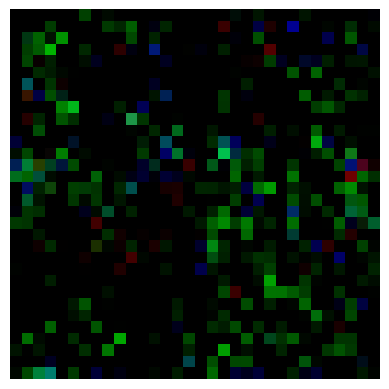

In [17]:
step_size = 5
num_inference_steps = 50
img_shape = (1, 3, 32, 32)

scheduler = pipeline.scheduler
scheduler.set_timesteps(num_inference_steps)

initial_noise = torch.randn(img_shape)

images = generate_images_with_intermediate_steps(pipeline, initial_noise, scheduler, num_inference_steps, step_size)

final_image = images[-1].squeeze().permute(1, 2, 0).cpu().numpy()
plt.imshow(final_image)
plt.axis('off')
plt.show()

image_paths = [f"imgs/step_{t}.png" for t in range(0, num_inference_steps, step_size)]
images_gif = [imageio.imread(path) for path in image_paths]
imageio.mimsave("gifs/step_by_step.gif", images_gif)

## Parte 8: Exploración del espacio latente entre dos imagenes

Vamos explorar el espacio latente entre dos imágenes. El objetivo es ver si podemos encontrar alguna relación entre las imagenes generadas por el movimiento del espacio latente entre dos imagenes.

### Proceso:
1. Generar dos estructuras con ruido diferente.
2. Interpolar entre ambas estructuras utilizando un valor de `alpha` que cambia de 0 a 1.
3. Pasar este ruido por el modelo de difusión.
4. Visualizar las imágenes generadas para observar la transición.

### Ejercicio:
- Completar código.
- ¿Qué es el espacio latente en un modelo de difusión y cómo se relaciona con las imágenes generadas?
- ¿Qué sucede cuando interpolamos entre dos estructuras de ruido diferentes utilizando un valor de alpha? ¿Qué esperarías ver en las imágenes generadas?
- Al visualizar las imágenes generadas por la interpolación, ¿observas alguna relación coherente entre las imágenes? ¿Las imágenes de la transición muestran características de ambas imágenes originales?

**Respuestas:**

El espacio latente en difusión es el espacio del ruido inicial. Cada punto en ese espacio (cada ruido inicial distinto) se mapea a una imagen diferente cuando pasa por el proceso de denoising.

Cuando interpolamos entre dos ruidos con alpha, estamos creando ruidos intermedios que son mezclas de ambos. Esperaríamos ver una transición gradual entre las dos imágenes que se generarían de cada ruido por separado.

Al observar las imágenes interpoladas, vemos que la transición no es tan suave como en otros modelos generativos. Cada imagen intermedia parece ser una imagen nueva y distinta, no necesariamente una mezcla visual de las dos originales. Esto pasa porque en los modelos de difusión el espacio del ruido no es un espacio latente aprendido como en las VAEs o GANs, sino que es simplemente ruido gaussiano. La relación entre el ruido y la imagen final es compleja y no lineal.

In [18]:
def denoise_image(unet_model, noisy_image, scheduler, num_inference_steps, num_steps_added_noise=0):
    image = noisy_image
    
    for t in range(num_inference_steps - num_steps_added_noise, num_inference_steps):
        current_timestep = scheduler.timesteps[t]
        
        with torch.no_grad():
            model_output = unet_model(image, current_timestep).sample
        
        image = scheduler.step(model_output, current_timestep, image).prev_sample
    
    return image

In [19]:
num_inference_steps = 50
scheduler = pipeline.scheduler
scheduler.set_timesteps(num_inference_steps)

image1_tensor = torch.randn((1, 3, 32, 32))
image2_tensor = torch.randn((1, 3, 32, 32))

steps = 10
interpolated_images = []
for alpha in np.linspace(0, 1, steps):
    interpolated_noise = (1 - alpha) * image1_tensor + alpha * image2_tensor
    
    interpolated_image = denoise_image(pipeline.unet, interpolated_noise, scheduler, num_inference_steps, num_inference_steps)
    
    interpolated_images.append(interpolated_image.cpu().detach())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8878293..0.5886178].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RG

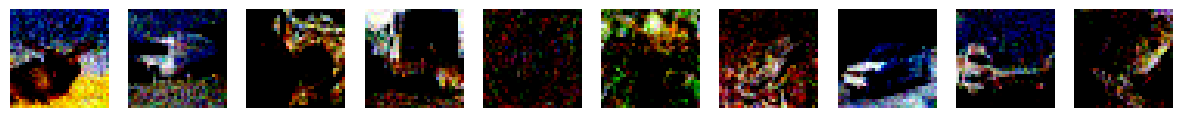

In [20]:
# Visualización de las imágenes interpoladas
plt.figure(figsize=(15, 3))
for i, img_tensor in enumerate(interpolated_images):
    img = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    plt.subplot(1, steps, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()

# Crear el GIF de la interpolación
images_for_gif = []
for img_tensor in interpolated_images:
    img = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img_uint8 = (img * 255).astype(np.uint8)  # Convertir a formato uint8 para el GIF
    images_for_gif.append(img_uint8)

# Guardar el GIF
imageio.mimsave('gifs/interpolation.gif', images_for_gif, duration=0.5)

## Parte 9: Añadir ruido controlado a una imagen real y eliminarlo

Vamos a tomar una imagen real del dataset, añadirle una cantidad controlada de ruido y luego intentaremos eliminar ese ruido utilizando el pipeline de difusión. Este proceso nos permitirá observar cómo el modelo reconstruye la imagen eliminando el ruido añadido.

### Pasos:
1. Seleccionar una imagen real del dataset CIFAR-10.
2. Añadir ruido gaussiano controlado a la imagen.
3. Usar el pipeline de difusión para eliminar el ruido y reconstruir la imagen original.

Este ejercicio ayuda a entender cómo los modelos de difusión pueden realizar la tarea de denoising en imágenes.

### Ejercicio:
- Completar código.
- ¿Qué es el ruido gaussiano y por qué lo añadimos a una imagen real en este ejercicio?
- ¿Cómo afecta la cantidad de ruido añadido a la imagen al proceso de denoising? ¿Qué esperarías que ocurriera si añades mucho ruido en comparación con poco?
- Si la cantidad de ruido añadido es muy alta, ¿crees que el modelo podrá eliminar todo el ruido y restaurar completamente la imagen original? ¿Por qué?
- ¿En qué escenarios prácticos crees que se podría aplicar este proceso de denoising en imágenes reales? ¿Qué aplicaciones puedes imaginar para esta técnica?

**Respuestas:**

El ruido gaussiano es ruido aleatorio que sigue una distribución normal. Lo añadimos para simular el proceso inverso de difusión y ver si el modelo puede reconstruir la imagen original.

Con mucho ruido el proceso de denoising es más difícil y puede que el modelo no recupere todos los detalles. Con poco ruido es más fácil recuperar la imagen casi perfecta.

Si el ruido es muy alto, el modelo probablemente no pueda restaurar completamente la imagen original porque se pierde mucha información. El modelo hace su mejor intento pero puede generar una imagen distinta.

Se podría aplicar en restauración de fotos viejas, mejora de imágenes médicas con ruido, limpieza de fotos tomadas con poca luz, o cualquier caso donde tengamos imágenes degradadas que queramos mejorar.

In [21]:
# Cargar el dataset CIFAR-10 y seleccionar una imagen
transform = transforms.Compose([transforms.ToTensor()])
dataset = CIFAR10(root="./data", train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
image, _ = next(iter(dataloader))  # Tomar una imagen del dataset

# Acceder al UNet y el scheduler del pipeline
unet_model = pipeline.unet
scheduler = pipeline.scheduler

100%|██████████| 170M/170M [05:08<00:00, 552kB/s]    


Extracting ./data\cifar-10-python.tar.gz to ./data


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4751235..2.484131].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.35842836..1.0].


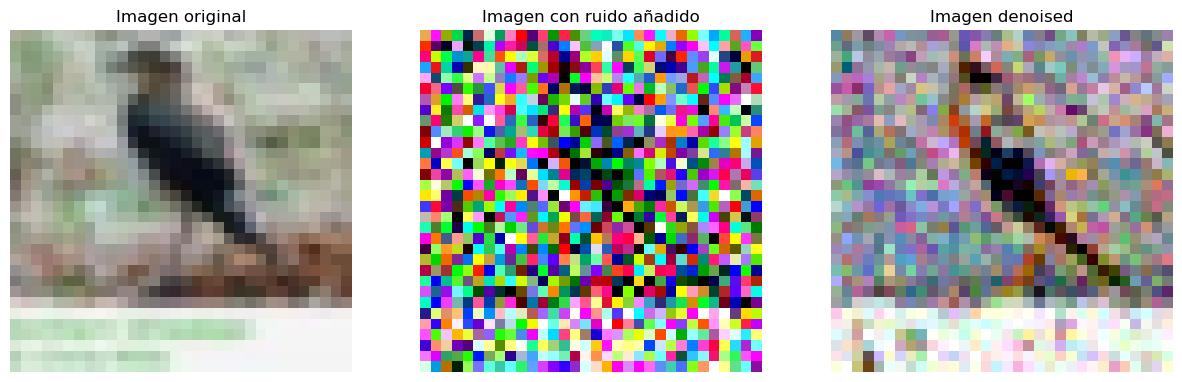

In [22]:
num_inference_steps = 50
num_steps_added_noise = 10
scheduler.set_timesteps(num_inference_steps)

timestep = scheduler.timesteps[-num_steps_added_noise]
with torch.no_grad():
    noisy_image = scheduler.add_noise(image, torch.randn_like(image), timestep)

denoised_image = denoise_image(unet_model, noisy_image, scheduler, num_inference_steps, num_steps_added_noise)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image.squeeze().permute(1, 2, 0).cpu().numpy())
plt.title("Imagen original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy_image.squeeze().permute(1, 2, 0).cpu().numpy())
plt.title("Imagen con ruido añadido")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(denoised_image.squeeze().permute(1, 2, 0).cpu().numpy())
plt.title("Imagen denoised")
plt.axis('off')

plt.show()